# Influence of Beta_ab


In [1]:
import os
import sys
import re  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
import matplotlib as mpl
import math
from collections import defaultdict
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker

from utils_mean_field import *
from script_mean_field_covid import *


main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils
sys.path.append(main_path + "covid/")
sys.path.append(main_path + "lattice/")
os.chdir(main_path + "covid/")

from global_variables import *
from utils_evaluate_seq import *
os.chdir('../mean_field_theory')
ab_names=list(ESCAPE_VECTORS.keys())


e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights
C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Loaded 29 KD vectors


# Order params

In [2]:


dir = 'results_scripts/covid_D_20/'

BETA_ABs = [0,1,5, 10]
D=1

def extract_parameters(path):
    beta_ab_match = re.search(r'beta_ab_(\d+(?:\.\d+)?)', path)
    D_match = re.search(r'D_(\d+)', path)
    return {
        "beta_ab": float(beta_ab_match.group(1)) if beta_ab_match else None,
        "D": int(D_match.group(1)) if D_match else None,
    }


all_dirs = [d for d in os.listdir(dir) if os.path.isdir(os.path.join(dir, d))]

paths = []
labels = []

for d in all_dirs:
    params = extract_parameters(d)
    if (
        params["beta_ab"] in BETA_ABs and
        params["D"] == D 
    ):
        paths.append(d)
        labels.append(params["beta_ab"])

for p, l in zip(paths, labels):
    print(f"{l}: {p}")



0.0: mean_f_free_ab_beta_ab_0_D_1
10.0: mean_f_free_ab_beta_ab_10_D_1
1.0: mean_f_free_ab_beta_ab_1_D_1
5.0: mean_f_free_ab_beta_ab_5_D_1


In [3]:

dir = '../mean_field_theory/results_scripts/covid_D_20/'

ab_names = list(ESCAPE_VECTORS.keys())

ab_class_df = pd.read_csv("../covid/exp_data/bloom_ab_classification/ab_classification.csv")
ab_to_class = dict(zip(ab_class_df['condition'].astype(str), ab_class_df['condition_subtype'].astype(str)))

class_to_indices = {}
for i, ab in enumerate(ab_names):
    cls = ab_to_class.get(ab, None)
    if cls is None:
        continue
    class_to_indices.setdefault(cls, []).append(i)

classes = [c for c, idxs in class_to_indices.items() if len(idxs) > 0]
classes = sorted(classes)

per_condition_series = {}  
for i, condition in enumerate(labels):
  

    mopt = np.load(os.path.join(dir, paths[i], "mopt.npy"))[:, :len(ab_names)]  # [steps, n_abs]
    Lm = 1-np.exp(mopt)  

    series = {}
    for cls in classes:
        idx = class_to_indices[cls]
        cls_mean = Lm[:, idx].mean(axis=1)  
        series[cls] = cls_mean
    per_condition_series[condition] = series



Calculating escape percentages for 4 conditions...
Calculation complete. Plotting...


<>:67: SyntaxWarning: invalid escape sequence '\%'
<>:67: SyntaxWarning: invalid escape sequence '\%'
C:\Users\maria\AppData\Local\Temp\ipykernel_13640\2359396010.py:67: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel("Percentage of Abs escaped (\%)")


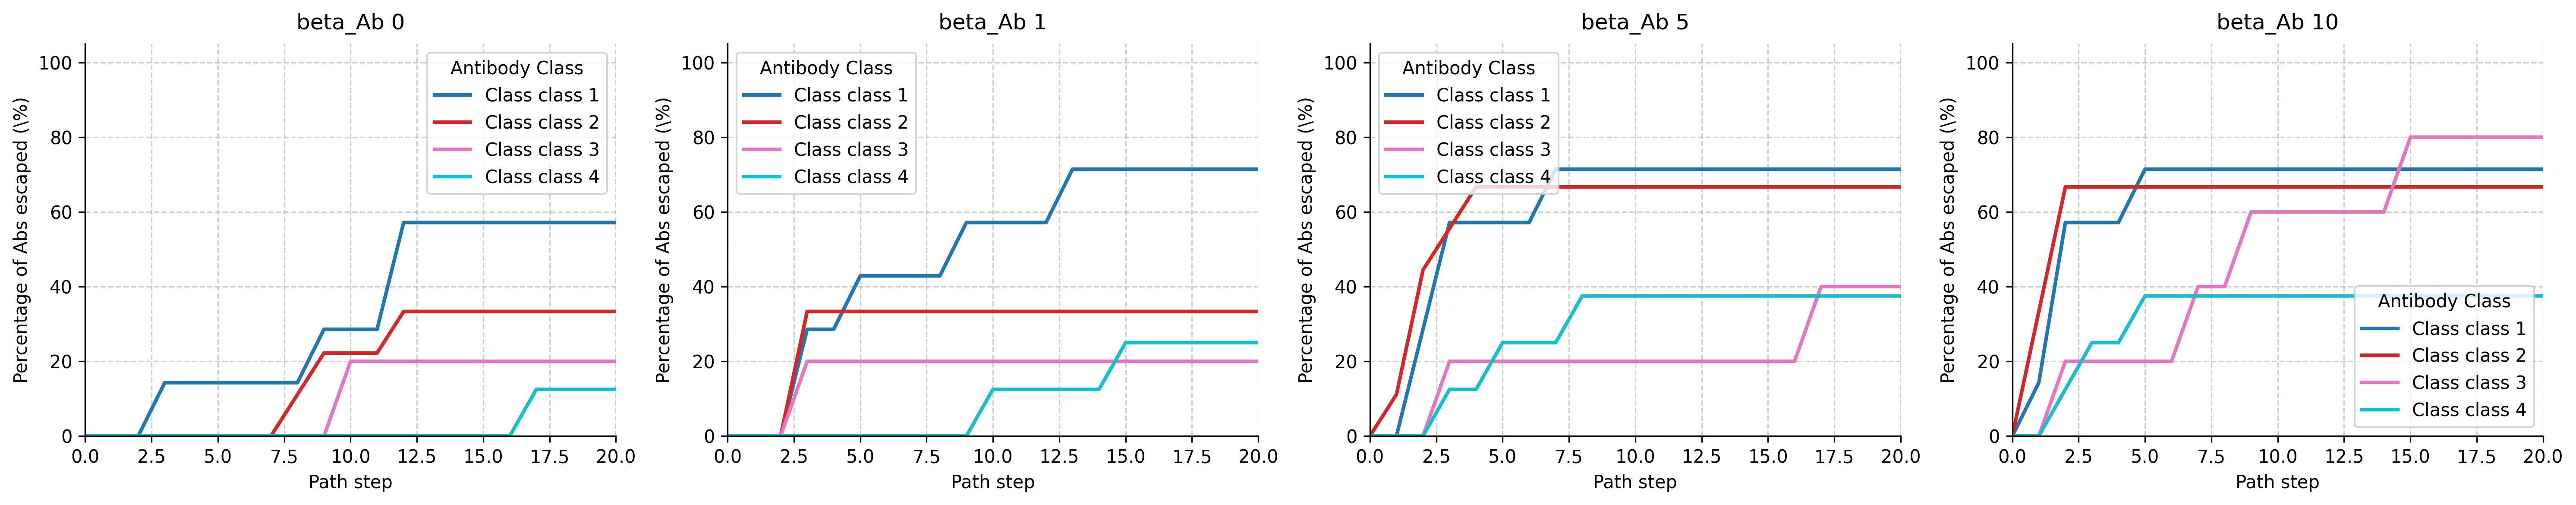

In [4]:

TH = np.log(0.1)
BG_ORDER = [c for c in BETA_ABs if c in per_condition_series]
classes = sorted([c for c, idxs in class_to_indices.items() if len(idxs) > 0])
n_classes = len(classes)

per_condition_escape_pct = {}
n_steps = 0 

label_to_index = {label: i for i, label in enumerate(labels)}
condition_indices = [(bg, label_to_index[bg]) for bg in BG_ORDER if bg in label_to_index]

print(f"Calculating escape percentages for {len(condition_indices)} conditions...")

for condition, i in condition_indices:
    mopt = np.load(os.path.join(dir, paths[i], "mopt.npy"))[:, :len(ab_names)] # [steps, n_abs]
    RAW =  mopt

    if n_steps == 0:
        n_steps = mopt.shape[0]

    class_pct_series = {}
    for cls in classes:
        idxs = class_to_indices[cls]
        total_in_class = len(idxs)

        if total_in_class == 0:
            class_pct_series[cls] = np.full(n_steps, np.nan)
            continue


        class_raw_data = RAW[:, idxs]

        escaped_bools = (class_raw_data <= TH)

        n_escaped_at_step = np.sum(escaped_bools, axis=1)
        pct_escaped_at_step = (n_escaped_at_step / total_in_class) * 100.0

        class_pct_series[cls] = pct_escaped_at_step

    per_condition_escape_pct[condition] = class_pct_series

print("Calculation complete. Plotting...")

n_bg = len(BG_ORDER)
fig, axes = plt.subplots(1, n_bg, figsize=(5 * n_bg, 4.0), squeeze=False, sharey=False, dpi=300)
axes = axes[0] 

x_steps = np.arange(n_steps)
colors = plt.colormaps['tab10'](np.linspace(0, 1, n_classes))

for i, (ax, condition) in enumerate(zip(axes, BG_ORDER)):
    if condition not in per_condition_escape_pct:
        ax.set_title(f"{condition}\n(No data)")
        continue

    class_series_map = per_condition_escape_pct[condition]

    for j, cls in enumerate(classes):
        y_pct = class_series_map[cls]
        ax.plot(x_steps, y_pct, label=f"Class {cls}", color=colors[j], linewidth=2)

    ax.set_title(f"beta_Ab {condition}", pad=8)
    ax.set_xlabel("Path step")
    ax.set_ylim(0, 105)
    ax.set_xlim(left=0, right=n_steps - 1)

    ax.set_ylabel("Percentage of Abs escaped (\%)")

    ax.legend(title="Antibody Class")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


fig.tight_layout()
plt.show()


Calculating mean binding for 4 conditions...
Calculation complete. Plotting...


C:\Users\maria\AppData\Local\Temp\ipykernel_13640\4141666018.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))


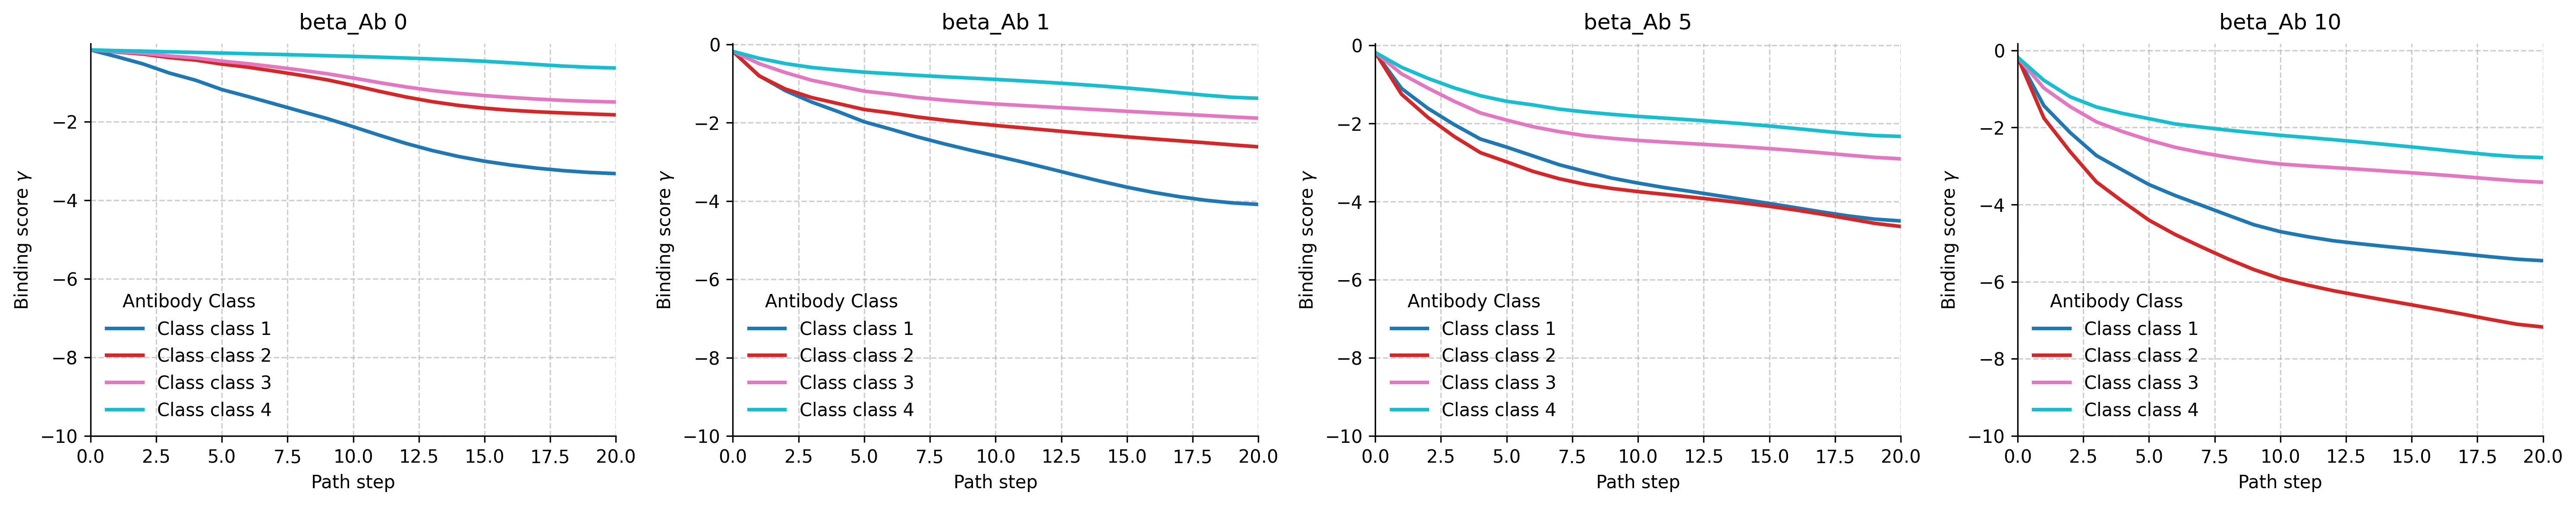

In [5]:



BG_ORDER = [c for c in BETA_ABs if c in per_condition_series]
classes = sorted([c for c, idxs in class_to_indices.items() if len(idxs) > 0])
n_classes = len(classes)

per_condition_mean_binding = {}
n_steps = 0 

label_to_index = {label: i for i, label in enumerate(labels)}
condition_indices = [(bg, label_to_index[bg]) for bg in BG_ORDER if bg in label_to_index]

print(f"Calculating mean binding for {len(condition_indices)} conditions...")

for condition, i in condition_indices:
   
    mopt = np.load(os.path.join(dir, paths[i], "mopt.npy"))[:, :len(ab_names)]
    RAW = mopt

    if n_steps == 0:
        n_steps = mopt.shape[0]

    class_binding_series = {}
    for cls in classes:
        idxs = class_to_indices[cls]
        total_in_class = len(idxs)

        if total_in_class == 0:
            class_binding_series[cls] = np.full(n_steps, np.nan)
            continue

     
        class_log_data = RAW[:, idxs]

        class_linear_data =class_log_data


        avg_binding_at_step = np.mean(class_linear_data, axis=1)

        class_binding_series[cls] = avg_binding_at_step

    per_condition_mean_binding[condition] = class_binding_series

print("Calculation complete. Plotting...")

n_bg = len(BG_ORDER)
fig, axes = plt.subplots(1, n_bg, figsize=(5 * n_bg, 4.0), squeeze=False, sharey=False, dpi=300)
axes = axes[0] 

x_steps = np.arange(n_steps)
colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))

for i, (ax, condition) in enumerate(zip(axes, BG_ORDER)):
    if condition not in per_condition_mean_binding:
        ax.set_title(f"{condition}\n(No data)")
        continue


    class_series_map = per_condition_mean_binding[condition]

    for j, cls in enumerate(classes):
        y_vals = class_series_map[cls]
        ax.plot(x_steps, y_vals, label=f"Class {cls}", color=colors[j], linewidth=2)

    ax.set_title(f"beta_Ab {condition}", pad=8)
    ax.set_xlabel("Path step")
    
    ax.set_ylim(bottom=-10)
    ax.set_xlim(left=0, right=n_steps - 1)

    ax.set_ylabel(r"Binding score $\gamma$")

    ax.legend(title="Antibody Class", frameon=False)
    
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.tight_layout()
plt.show()


# Most probable sequence start WT

In [6]:
D=1

In [7]:
wt_seq=WT[BEGIN:-END]
dir = '../mean_field_theory/results_scripts/covid_D_20/'
paths=[f'mean_f_free_ab_beta_ab_0_D_{D}.npy', f'mean_f_free_ab_beta_ab_1_D_{D}.npy',    f'mean_f_free_ab_beta_ab_5_D_{D}.npy', f'mean_f_free_ab_beta_ab_10_D_{D}.npy']
labels=['beta_Ab=0','beta_Ab=1','beta_Ab=5', 'beta_Ab=10']

In [8]:





mpl.rcParams.update({
    "text.usetex": True,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14
})


mut_vs_wt   = {} 
mut_vs_init = {}   
for i, condition in enumerate(labels):

    path_proba = np.load(os.path.join(dir, paths[i]))  # shape: (T-1,)
    print(condition)
    final_state = np.argmax(path_proba, axis=0)[-1]
    seq = Proteins_utils.num2seq(final_state)

    mutations_wt = []
    for i, (wt_aa, mut_aa) in enumerate(zip(wt_seq, seq)):
        if wt_aa != mut_aa:
            site = 349 + i
            mutation = f"{wt_aa}{site}{mut_aa}"
            mutations_wt.append(mutation)
    print('mutations vs wt', mutations_wt)


    init_state = np.argmax(path_proba, axis=0)[0]
    init_state = Proteins_utils.num2seq(init_state)

    mutations_init = []
    for i, (wt_aa, mut_aa) in enumerate(zip(init_state, seq)):
        if wt_aa != mut_aa:
            site = 349 + i
            mutation = f"{wt_aa}{site}{mut_aa}"
            mutations_init.append(mutation)
    print('mutations vs init', mutations_init)
    mut_vs_wt[condition]   = mutations_wt          # list of strings
    mut_vs_init[condition] = mutations_init





beta_Ab=0
mutations vs wt ['R357T', 'A363F', 'Y365I', 'A372K', 'S375G', 'N394K', 'K417V', 'N450T', 'R457A', 'N487D', 'Q498H', 'L518T', 'H519A']
mutations vs init ['R357T', 'A363F', 'Y365I', 'A372K', 'S375G', 'N394K', 'K417V', 'N450T', 'R457A', 'N487D', 'Q498H', 'L518T', 'H519A']
beta_Ab=1
mutations vs wt ['R357T', 'A363W', 'Y365I', 'A372K', 'K378E', 'N394K', 'K417V', 'N440D', 'N450T', 'R457A', 'N487D', 'Q498H', 'L518T', 'H519A']
mutations vs init ['R357T', 'A363W', 'Y365I', 'A372K', 'K378E', 'N394K', 'K417V', 'N440D', 'N450T', 'R457A', 'N487D', 'Q498H', 'L518T', 'H519A']
beta_Ab=5
mutations vs wt ['R357T', 'A363W', 'Y365I', 'A372K', 'K378E', 'T385E', 'N394K', 'K417V', 'N450T', 'N487R', 'Q498D', 'L518T', 'H519D']
mutations vs init ['R357T', 'A363W', 'Y365I', 'A372K', 'K378E', 'T385E', 'N394K', 'K417V', 'N450T', 'N487R', 'Q498D', 'L518T', 'H519D']
beta_Ab=10
mutations vs wt ['A363W', 'Y365I', 'A372K', 'K378E', 'S383E', 'N394K', 'K417E', 'V445D', 'N450T', 'F486P', 'N487R', 'F490R', 'Q498D

In [9]:
VOCS_MUTS=[332, 339, 346, 356, 368, 371, 373, 375, 376, 403, 405, 408, 417, 440, 444, 445, 446, 450, 452, 455, 456, 460, 477, 478, 481, 484,486, 490, 493, 496, 498, 501, 505 ]


C:\Users\maria\AppData\Local\Temp\ipykernel_13640\148942458.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(active_counts_per_class))


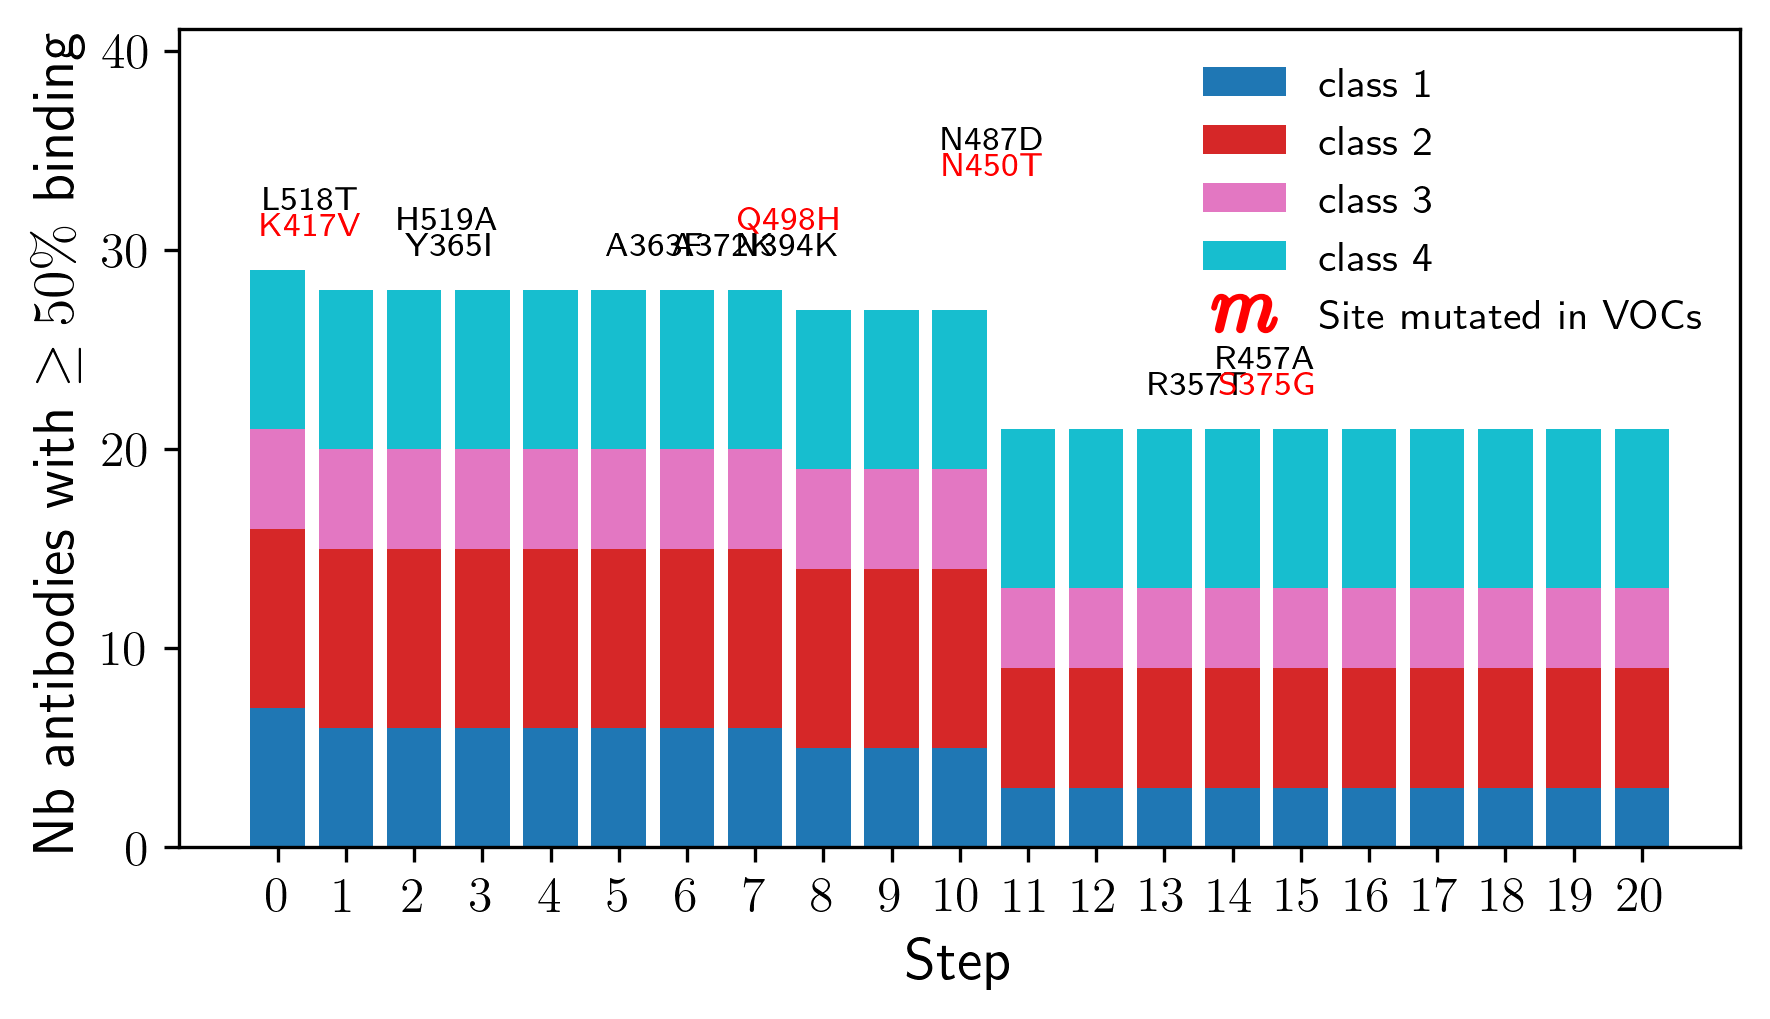

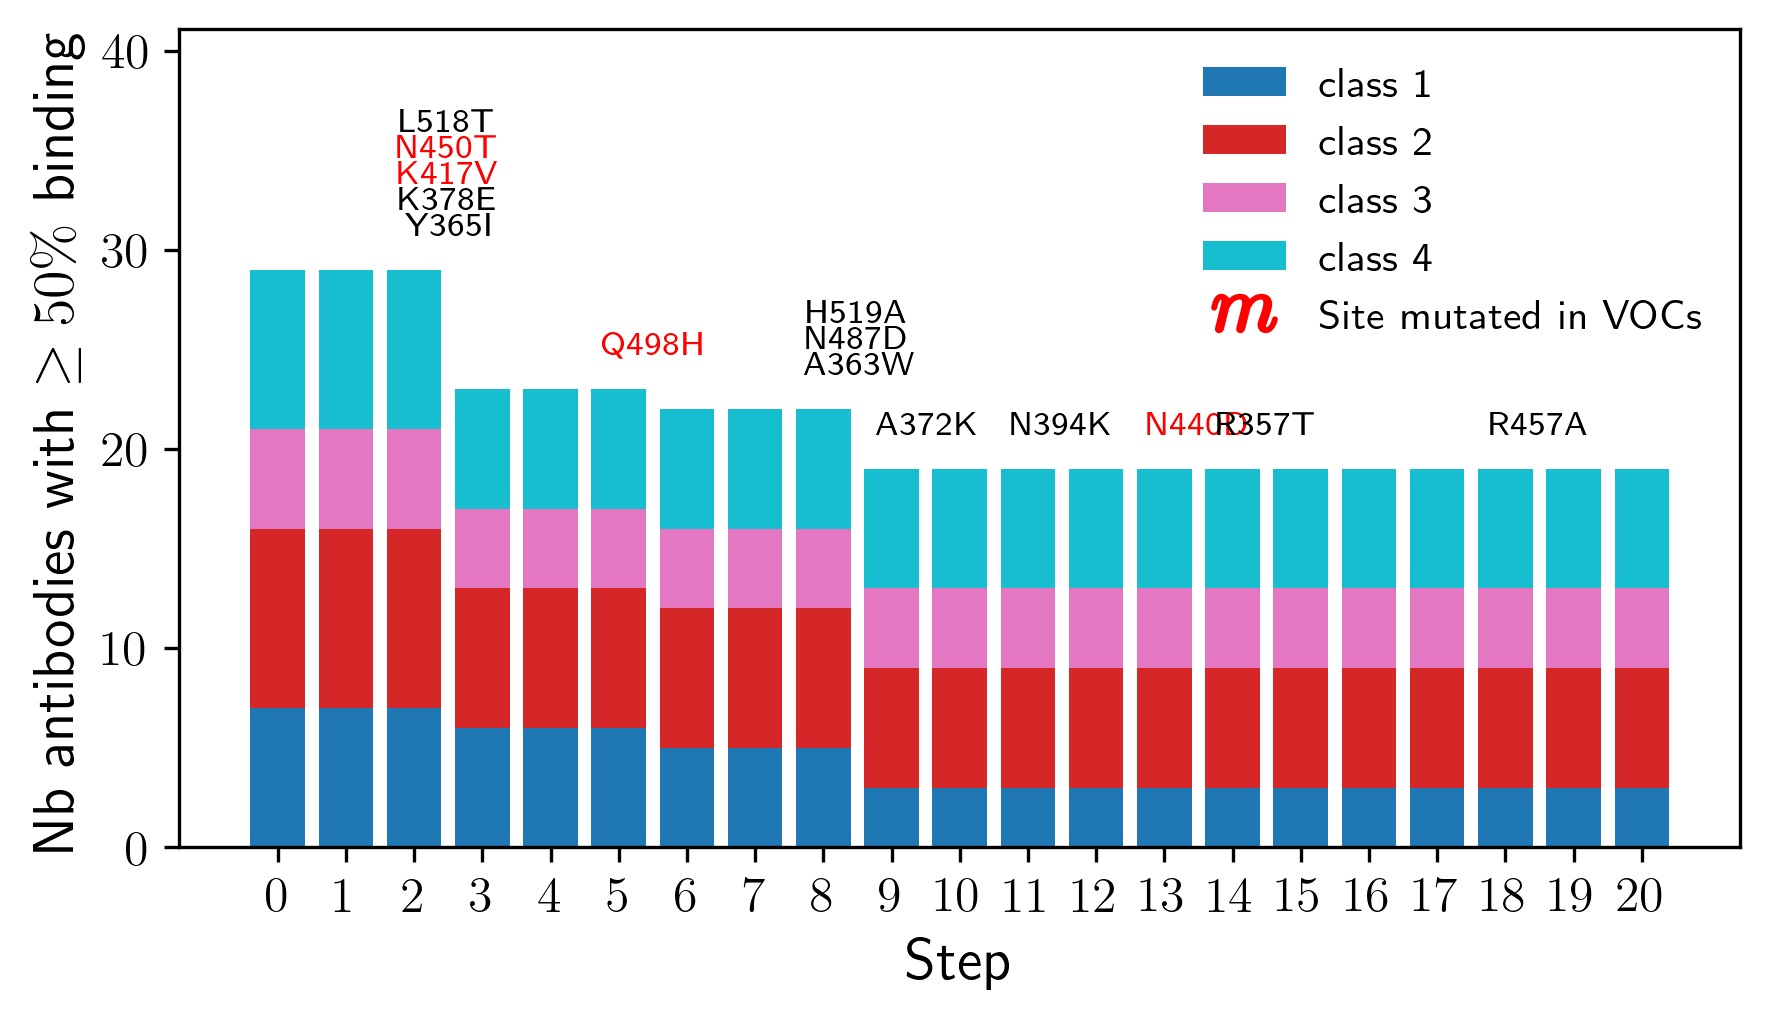

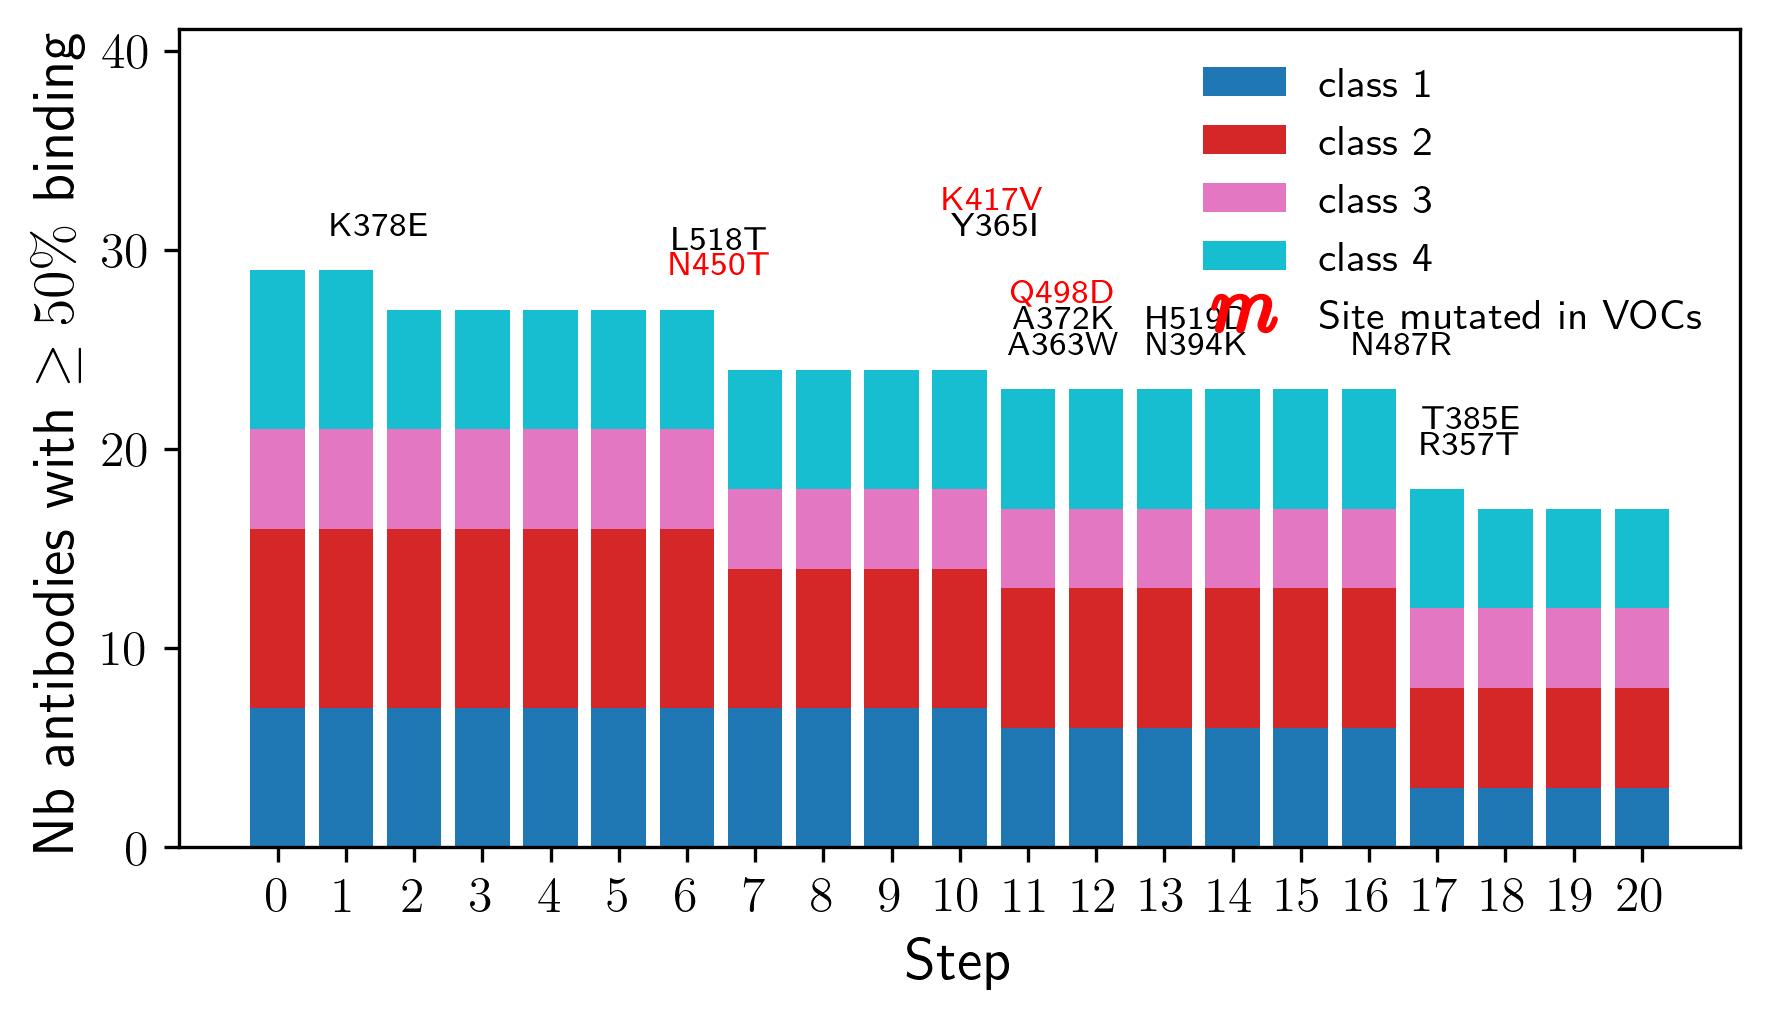

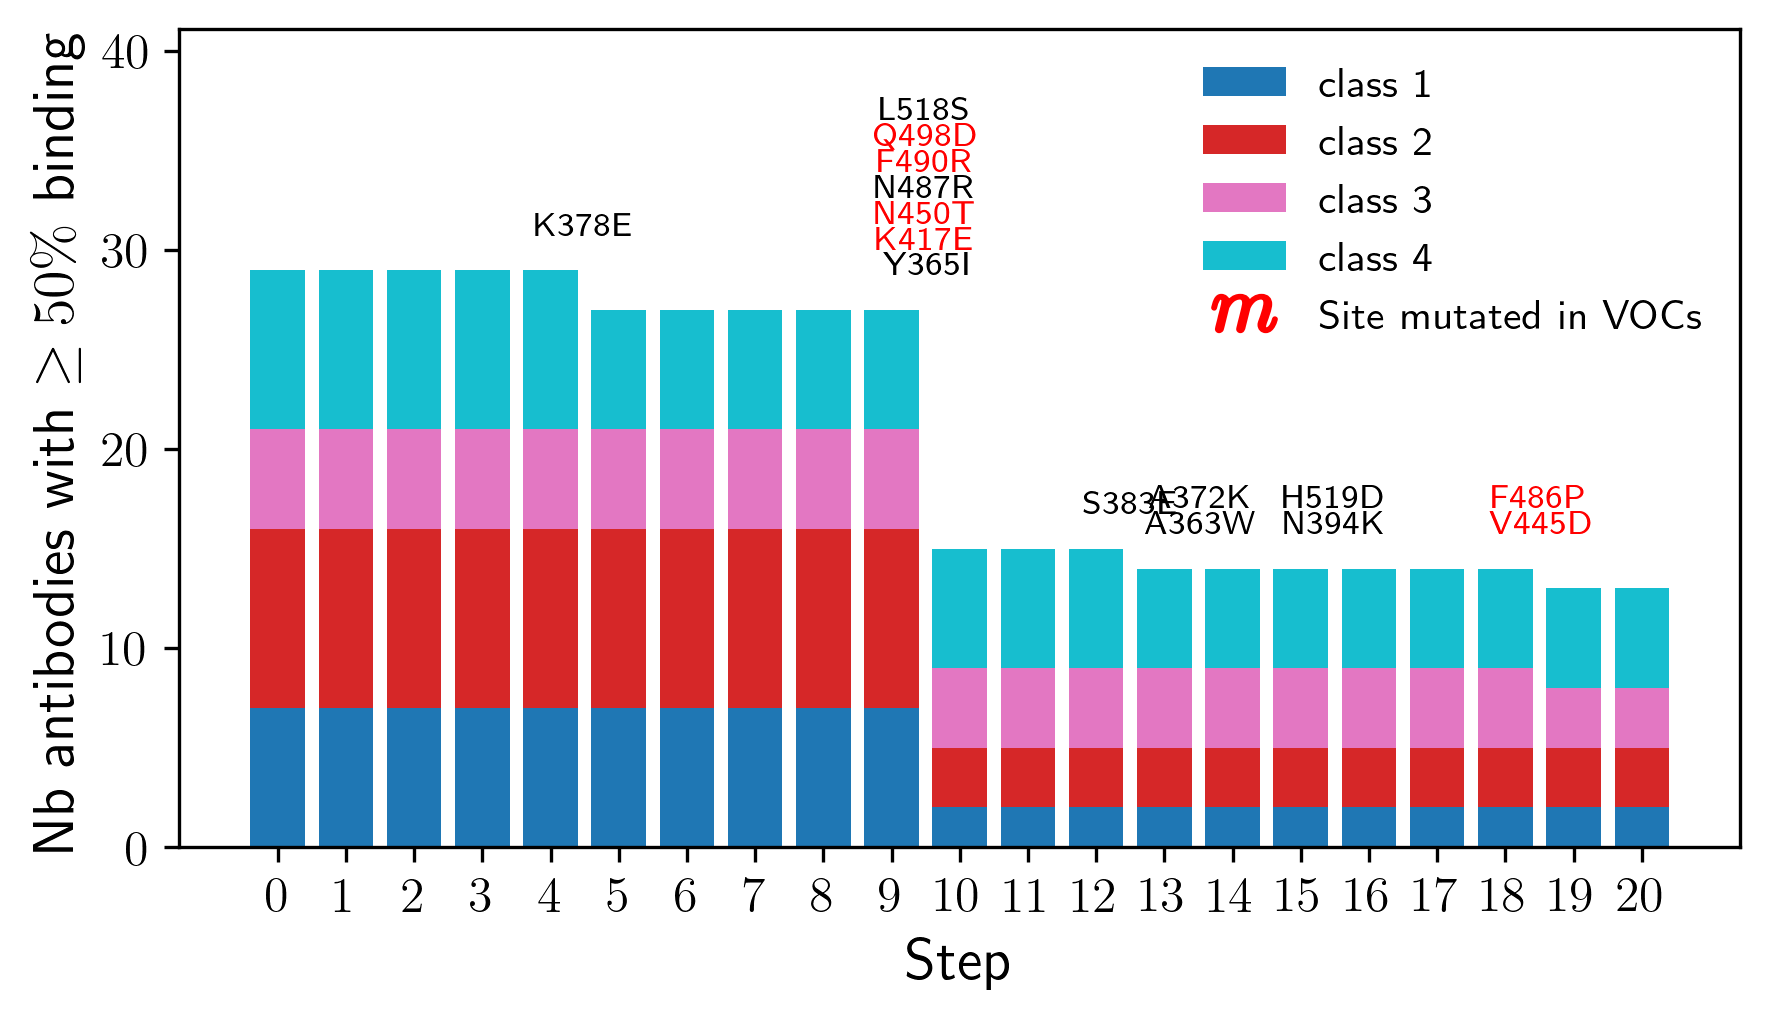

In [10]:


VOCS_MUTS = [
    332, 339, 346, 356, 368, 371, 373, 375, 376, 403, 405, 408, 417, 
    440, 444, 445, 446, 450, 452, 455, 456, 460, 477, 478, 481, 484,
    486, 490, 493, 496, 498, 501, 505
]

TH = np.log(0.1)

ab_class_df = pd.read_csv("../covid/exp_data/bloom_ab_classification/ab_classification.csv")

ab_names = list(ESCAPE_VECTORS.keys())
ab_to_class = dict(zip(ab_class_df['condition'], ab_class_df['condition_subtype']))

class_to_indices = defaultdict(list)
for i, ab in enumerate(ab_names):
    ab_class = ab_to_class.get(ab)
    if ab_class:
        class_to_indices[ab_class].append(i)

class_to_indices = dict(sorted(class_to_indices.items()))

for path_idx, path in enumerate(paths):
    path_proba = np.load(dir + path)  # Load path data
    path_proba = np.argmax(path_proba, axis=0)

    escapes = np.array([get_log_bindings(path_proba[i]) for i in range(path_proba.shape[0])])

    seqs = [Proteins_utils.num2seq(row) for row in path_proba]

    mut_per_step = [""]
    for i in range(1, len(seqs)):
        prev, curr = seqs[i - 1], seqs[i]
        muts = [
            f"{a_old}{348+pos}{a_new}"
            for pos, (a_old, a_new) in enumerate(zip(prev, curr), start=1)
            if a_old != a_new
        ]
        mut_per_step.append("\n".join(muts))

    active_abs = escapes > TH  # Boolean mask
    
    active_counts_per_class = {}
    for ab_class, indices in class_to_indices.items():
        active_counts_per_class[ab_class] = np.sum(active_abs[:, indices], axis=1)

    plt.figure(figsize=(6, 3.5), dpi=300)
    steps = np.arange(path_proba.shape[0])
    bottoms = np.zeros(len(steps))
    
    colors = plt.cm.get_cmap('tab10', len(active_counts_per_class))
    
    for i, (ab_class, counts) in enumerate(active_counts_per_class.items()):
        plt.bar(steps, counts, bottom=bottoms, label=ab_class, color=colors(i))
        bottoms += counts  # Update bottoms for the next layer


    total_heights = bottoms
    y_padding = (np.max(total_heights) if np.max(total_heights) > 0 else 1) * 0.05
    text_line_height = y_padding * 0.9

    for s in range(1, len(mut_per_step)):
        if mut_per_step[s]:
            x_pos = s - 0.5
            y_base = max(total_heights[s-1], total_heights[s]) + y_padding
            

            mut_lines = mut_per_step[s].split('\n')
            
            for i, mut in enumerate(mut_lines):
                match = re.search(r'(\d+)', mut)
                site_num = int(match.group(1)) if match else -1
                
                if site_num in VOCS_MUTS:
                    text_color = 'red'
                else:
                    text_color = 'black'

                if s==11:
                    plt.text(
                        x_pos, 
                        y_base + (i * text_line_height+5), 
                        mut,
                        ha="center", va="bottom",
                        fontsize=8, 
                        color=text_color, 
                        fontweight='bold'
                    )
                else:
                    plt.text(
                        x_pos, 
                        y_base + (i * text_line_height), 
                        mut,
                        ha="center", va="bottom",
                        fontsize=8, 
                        color=text_color, 
                        fontweight='bold'
                    )

    plt.xlabel("Step", fontsize=14)
    plt.ylabel(r"Nb antibodies with $\geq 50\%$ binding", fontsize=14)
    
    handles, labels_legend = plt.gca().get_legend_handles_labels()
    
    red_text = plt.Line2D(
        [0], [0], 
        color='red', 
        marker='$m$',   # The $...$ syntax turns the string into a marker
        linestyle='None', 
        markersize=15,    # Increase size so the text is readable
        label='Site mutated in VOCs'
    )    
    handles.append(red_text)
    plt.legend(handles=handles, frameon=False)
    
    ax = plt.gca()

    ax.tick_params(axis='both', which='major', labelsize=12)
    plt.xticks(steps)
    
    current_ylim = plt.ylim()[1]
    plt.ylim(0, current_ylim * 1.35) # Increase upper limit by 35%

    plt.tight_layout()
    plt.show()


# Most probable sequence start BA.1

In [11]:
wt_seq=WT[BEGIN:-END]
D=1
dir = '../mean_field_theory/results_scripts/covid_D_20_ba1/'
paths=[f'ba1_mean_f_free_ab_beta_ab_0_D_{D}.npy', f'ba1_mean_f_free_ab_beta_ab_1_D_{D}.npy', f'ba1_mean_f_free_ab_beta_ab_5_D_{D}.npy', f'ba1_mean_f_free_ab_beta_ab_10_D_{D}.npy']
labels=['beta_Ab=0','beta_Ab=1','beta_Ab=5' , 'beta_Ab=10']

In [12]:
VOCS_MUTS_POST_BA1=[332, 346, 356, 368, 376, 403, 405, 408,  444, 445, 450, 452, 455, 456, 460, 481, 486, 490]

<>:73: SyntaxWarning: invalid escape sequence '\%'
<>:73: SyntaxWarning: invalid escape sequence '\%'
C:\Users\maria\AppData\Local\Temp\ipykernel_13640\1019663682.py:73: SyntaxWarning: invalid escape sequence '\%'
  plt.title(f"BA1 start, active Antibodies (At least 50\% binding) \n{labels[path_idx]}")
C:\Users\maria\AppData\Local\Temp\ipykernel_13640\1019663682.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(active_counts_per_class))


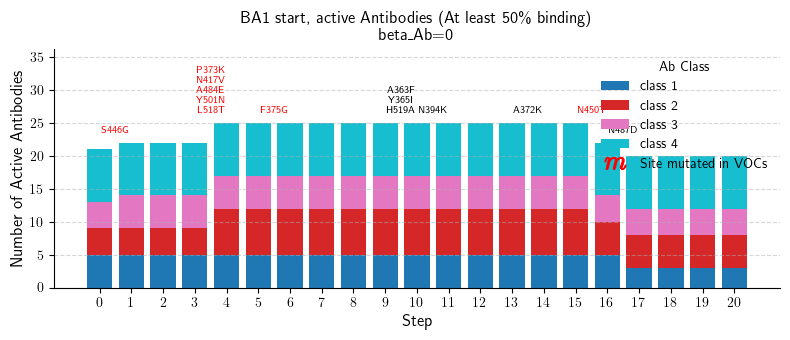

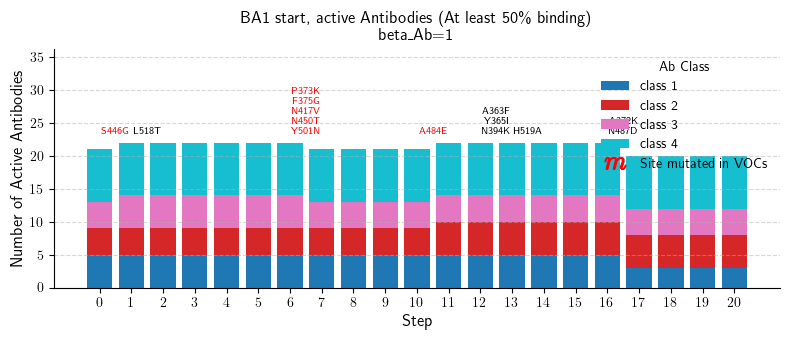

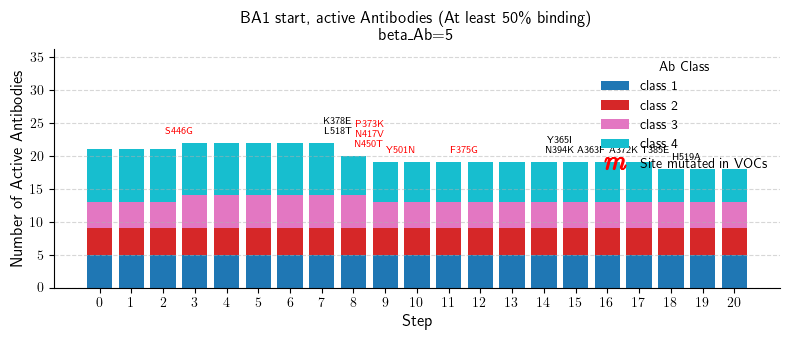

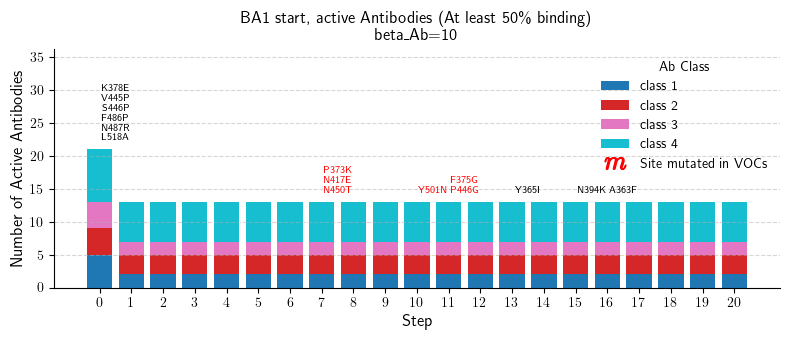

In [13]:

ab_class_df = pd.read_csv("../covid/exp_data/bloom_ab_classification/ab_classification.csv")

ab_names = list(ESCAPE_VECTORS.keys())
ab_to_class = dict(zip(ab_class_df['condition'], ab_class_df['condition_subtype']))

class_to_indices = defaultdict(list)
for i, ab in enumerate(ab_names):
    ab_class = ab_to_class.get(ab)
    if ab_class:
        class_to_indices[ab_class].append(i)

class_to_indices = dict(sorted(class_to_indices.items()))

for path_idx, path in enumerate(paths):
    path_proba = np.load(dir + path)  # Load path data
    path_proba = np.argmax(path_proba, axis=0)

    escapes = np.array([get_log_bindings(path_proba[i]) for i in range(path_proba.shape[0])])

    seqs = [Proteins_utils.num2seq(row) for row in path_proba]

    mut_per_step = [""]
    for i in range(1, len(seqs)):
        prev, curr = seqs[i - 1], seqs[i]
        muts = [
            f"{a_old}{348+pos}{a_new}"
            for pos, (a_old, a_new) in enumerate(zip(prev, curr), start=1)
            if a_old != a_new
        ]
        mut_per_step.append("\n".join(muts))

    active_abs = escapes > TH  # Boolean mask
    
    active_counts_per_class = {}
    for ab_class, indices in class_to_indices.items():
        active_counts_per_class[ab_class] = np.sum(active_abs[:, indices], axis=1)

    plt.figure(figsize=(8, 3.5))
    steps = np.arange(path_proba.shape[0])
    bottoms = np.zeros(len(steps))
    
    colors = plt.cm.get_cmap('tab10', len(active_counts_per_class))
    
    for i, (ab_class, counts) in enumerate(active_counts_per_class.items()):
        plt.bar(steps, counts, bottom=bottoms, label=ab_class, color=colors(i))
        bottoms += counts  # Update bottoms for the next layer

  
    total_heights = bottoms
    y_padding = (np.max(total_heights) if np.max(total_heights) > 0 else 1) * 0.05

    for s in range(1, len(mut_per_step)):
        if mut_per_step[s]:
            x_pos = s - 0.5
            y_pos = max(total_heights[s-1], total_heights[s]) + y_padding
            if int(mut_per_step[s][1:4]) in VOCS_MUTS:
                plt.text(
                    x_pos, y_pos,
                    mut_per_step[s],
                    ha="center", va="bottom",
                    fontsize=7, color='red', fontweight='bold'
                )
            else:
                plt.text(
                    x_pos, y_pos,
                    mut_per_step[s],
                    ha="center", va="bottom",
                    fontsize=7, fontweight='bold'
                )

    plt.xlabel("Step", fontsize=12)
    plt.ylabel("Number of Active Antibodies", fontsize=12)
    plt.title(f"BA1 start, active Antibodies (At least 50\% binding) \n{labels[path_idx]}")
    handles, labels_legend = plt.gca().get_legend_handles_labels()
    red_text = plt.Line2D(
        [0], [0], 
        color='red', 
        marker='$m$',   
        linestyle='None', 
        markersize=15,    
        label='Site mutated in VOCs'
    )    
    handles.append(red_text)
    plt.legend(handles=handles, frameon=False, title="Ab Class", loc='upper right')
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(steps)
    
    plt.ylim(0, 29 * 1.25)

    plt.tight_layout()
    plt.show()

# Comparison BA1 vs WT start

C:\Users\maria\AppData\Local\Temp\ipykernel_13640\1617444101.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))


Generating separate plots for Betas: [5] (D=1)...


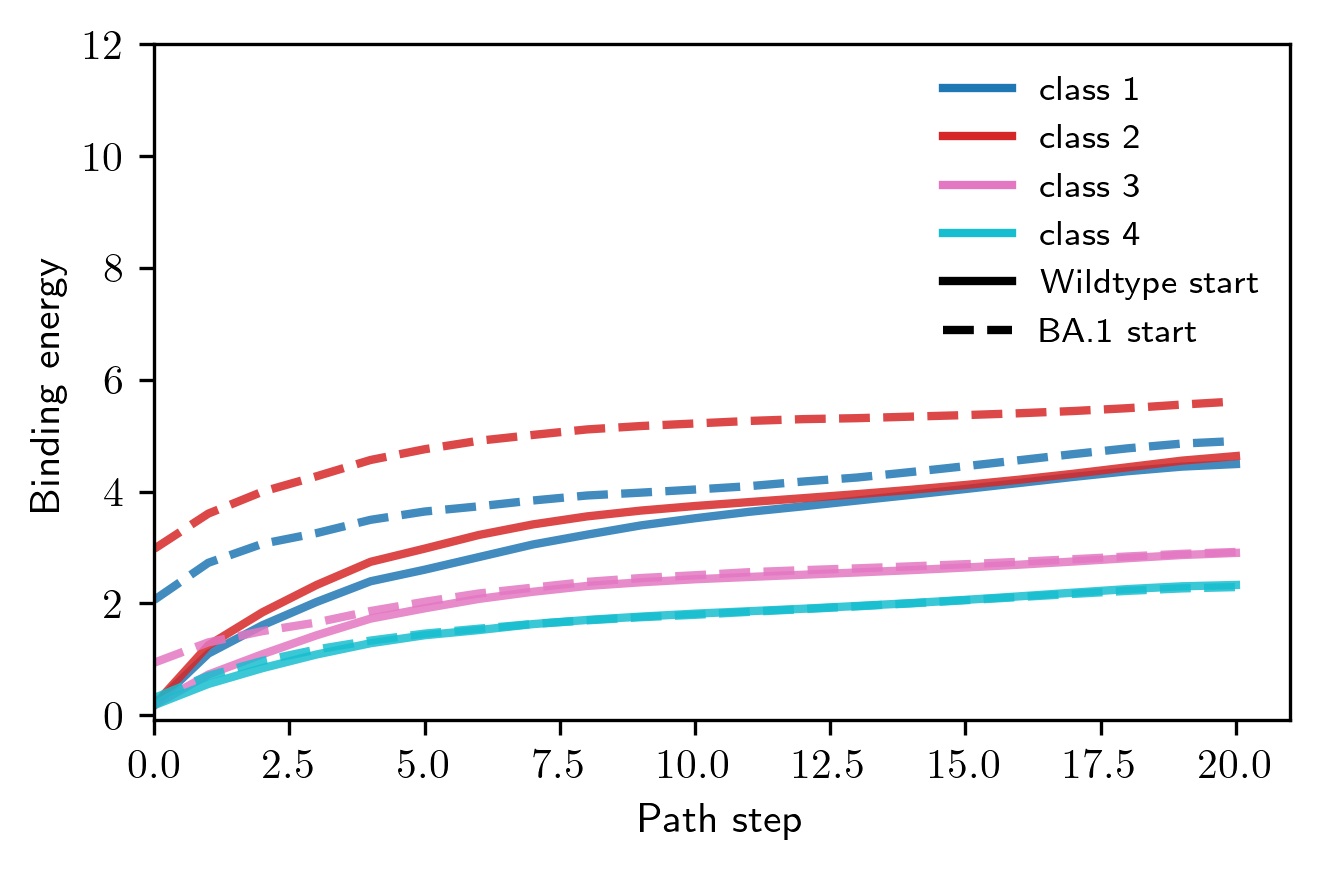

In [14]:

dir_wt  = 'results_scripts/covid_D_20/'
dir_ba1 = 'results_scripts/covid_D_20_ba1/'

BETA_ABs = [5]
D_FIXED = 1



classes = sorted([c for c, idxs in class_to_indices.items() if len(idxs) > 0])
n_classes = len(classes)

colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))
color_map = {cls: colors[i] for i, cls in enumerate(classes)}

def extract_parameters(path):
    beta_ab_match = re.search(r'beta_ab_(\d+(?:\.\d+)?)', path)
    D_match = re.search(r'D_(\d+)', path)
    return {
        "beta_ab": float(beta_ab_match.group(1)) if beta_ab_match else None,
        "D": int(D_match.group(1)) if D_match else None,
    }

def find_folder(root_dir, target_beta, target_D):
    if not os.path.exists(root_dir):
        return None
    for d in os.listdir(root_dir):
        full_path = os.path.join(root_dir, d)
        if os.path.isdir(full_path):
            params = extract_parameters(d)
            if (params["beta_ab"] is not None and 
                np.isclose(params["beta_ab"], target_beta) and 
                params["D"] == target_D):
                return full_path
    return None

def process_binding_data(folder_path):
    mopt_path = os.path.join(folder_path, "mopt.npy")
    if not os.path.exists(mopt_path):
        return None, 0

    mopt = np.load(mopt_path)[:, :len(ab_names)]
    n_steps = mopt.shape[0]
    
    class_series = {}
    for cls in classes:
        idxs = class_to_indices[cls]
        if len(idxs) == 0:
            class_series[cls] = np.full(n_steps, np.nan)
        else:
            class_log_data = mopt[:, idxs]
            avg_binding = np.mean(class_log_data, axis=1)
            class_series[cls] = avg_binding
            
    return class_series, n_steps


variants = [
    ("Wildtype", dir_wt, "-"),    # Solid
    ("BA1",      dir_ba1, "--")   # Dashed
]

print(f"Generating separate plots for Betas: {BETA_ABs} (D={D_FIXED})...")

for beta in BETA_ABs:
    if beta!=5:
        continue
    fig = plt.figure(figsize=(4.5, 3), dpi=300)
    ax = plt.gca()
    
    max_steps_in_plot = 0
    data_found = False

    for variant_label, root_dir, style in variants:
        folder = find_folder(root_dir, beta, D_FIXED)
        
        if folder:
            data, steps = process_binding_data(folder)
            
            if data:
                data_found = True
                max_steps_in_plot = max(max_steps_in_plot, steps)
                x_vals = np.arange(steps)
                
                for cls in classes:
                    y_vals = -data[cls]
                    ax.plot(x_vals, y_vals, 
                             color=color_map[cls], 
                             linestyle=style, 
                             linewidth=2, 
                             alpha=0.85)
        else:
            print(f"  [Warning] Missing {variant_label} folder for Beta={beta}")

    ax.set_xlabel("Path step")
    ax.set_ylabel("Binding energy")
    ax.set_ylim(top=12)
    
    if max_steps_in_plot > 0:
        ax.set_xlim(0, max_steps_in_plot)
    
    
    if data_found:
        legend_elements = []

        for cls in classes:
            legend_elements.append(Line2D([0], [0], color=color_map[cls], lw=2, label=cls))
        
        legend_elements.append(Line2D([0], [0], color='black', lw=2, linestyle='-', label='Wildtype start'))
        legend_elements.append(Line2D([0], [0], color='black', lw=2, linestyle='--', label='BA.1 start'))
        
        ax.legend(handles=legend_elements, loc='best', frameon=False, fontsize='small')
    else:
        ax.text(0.5, 0.5, "No Data Found", ha='center', transform=ax.transAxes)

    plt.tight_layout()
  
    plt.show()

<>:95: SyntaxWarning: invalid escape sequence '\%'
<>:95: SyntaxWarning: invalid escape sequence '\%'
C:\Users\maria\AppData\Local\Temp\ipykernel_13640\1345206410.py:95: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel("Average binding (\%)")
C:\Users\maria\AppData\Local\Temp\ipykernel_13640\1345206410.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))


Generating separate plots for Betas: [5] (D=1)...


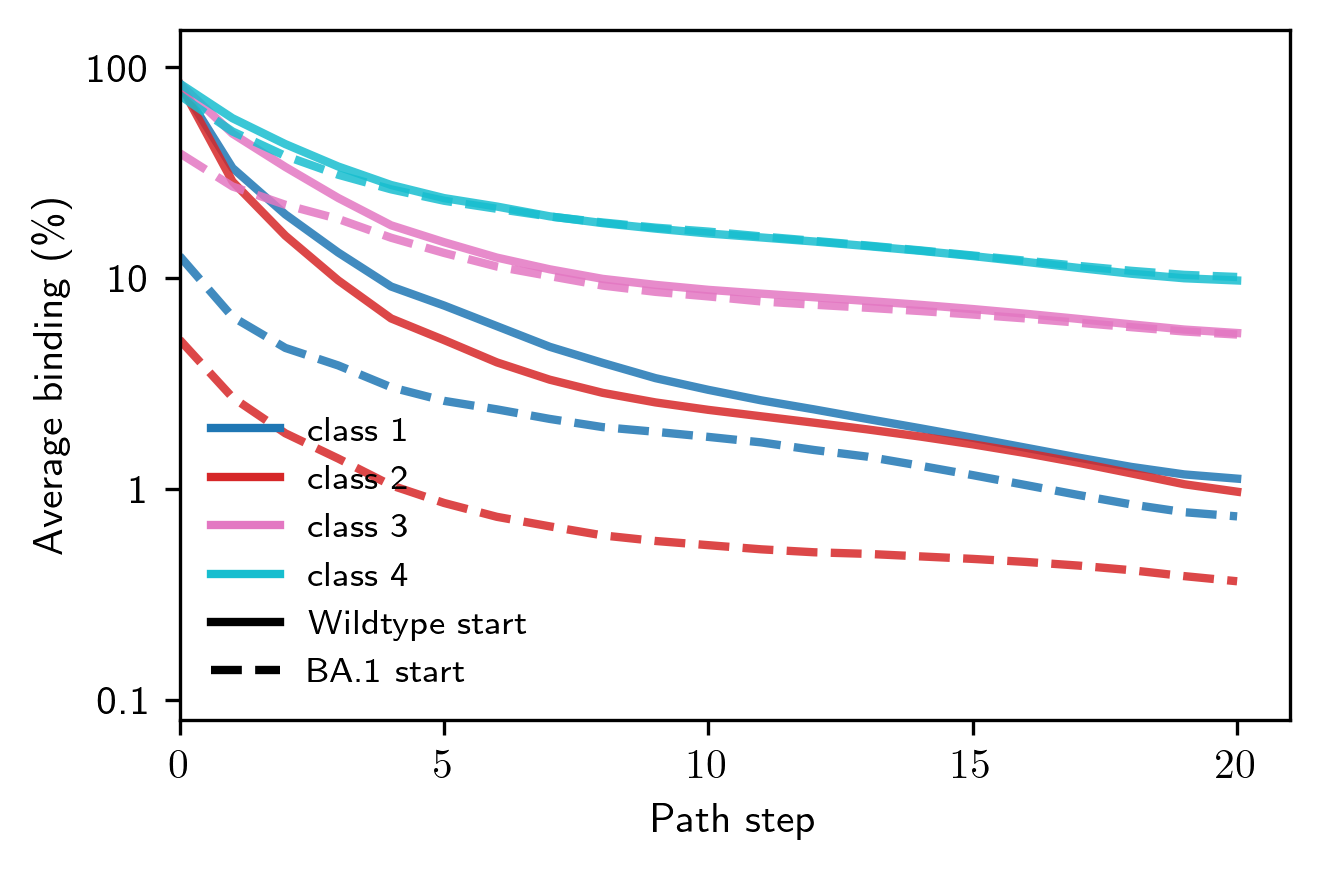

In [15]:



dir_wt  = 'results_scripts/covid_D_20/'
dir_ba1 = 'results_scripts/covid_D_20_ba1/'

BETA_ABs = [5]
D_FIXED = 1


classes = sorted([c for c, idxs in class_to_indices.items() if len(idxs) > 0])
n_classes = len(classes)

colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))
color_map = {cls: colors[i] for i, cls in enumerate(classes)}

def extract_parameters(path):
    beta_ab_match = re.search(r'beta_ab_(\d+(?:\.\d+)?)', path)
    D_match = re.search(r'D_(\d+)', path)
    return {
        "beta_ab": float(beta_ab_match.group(1)) if beta_ab_match else None,
        "D": int(D_match.group(1)) if D_match else None,
    }

def find_folder(root_dir, target_beta, target_D):
    if not os.path.exists(root_dir):
        return None
    for d in os.listdir(root_dir):
        full_path = os.path.join(root_dir, d)
        if os.path.isdir(full_path):
            params = extract_parameters(d)
            if (params["beta_ab"] is not None and 
                np.isclose(params["beta_ab"], target_beta) and 
                params["D"] == target_D):
                return full_path
    return None

def process_binding_data(folder_path):
    mopt_path = os.path.join(folder_path, "mopt.npy")
    if not os.path.exists(mopt_path):
        return None, 0

    mopt = np.load(mopt_path)[:, :len(ab_names)]
    n_steps = mopt.shape[0]
    
    class_series = {}
    for cls in classes:
        idxs = class_to_indices[cls]
        if len(idxs) == 0:
            class_series[cls] = np.full(n_steps, np.nan)
        else:
            class_log_data = mopt[:, idxs]
            avg_binding = np.mean(class_log_data, axis=1)
            class_series[cls] = avg_binding
            
    return class_series, n_steps

variants = [
    ("Wildtype", dir_wt, "-"),    # Solid
    ("BA1",      dir_ba1, "--")   # Dashed
]

print(f"Generating separate plots for Betas: {BETA_ABs} (D={D_FIXED})...")

for beta in BETA_ABs:
    if beta != 5:
        continue
    fig = plt.figure(figsize=(4.5, 3), dpi=300)
    ax = plt.gca()
    
    max_steps_in_plot = 0
    data_found = False

    for variant_label, root_dir, style in variants:
        folder = find_folder(root_dir, beta, D_FIXED)
        
        if folder:
            data, steps = process_binding_data(folder)
            
            if data:
                data_found = True
                max_steps_in_plot = max(max_steps_in_plot, steps)
                x_vals = np.arange(steps)
                
                for cls in classes:
                    # Convert fraction to Percentage (multiply by 100)
                    y_vals = np.exp(data[cls]) * 100
                    
                    ax.plot(x_vals, y_vals, 
                             color=color_map[cls], 
                             linestyle=style, 
                             linewidth=2, 
                             alpha=0.85)
        else:
            print(f"  [Warning] Missing {variant_label} folder for Beta={beta}")

    ax.set_xlabel("Path step")
    ax.set_ylabel("Average binding (\%)")
    
    ax.set_yscale('log')
    
    ax.set_ylim(0.08, 150)
    ax.set_yticks([0.1, 1, 10, 100])
    
    ax.get_yaxis().set_major_formatter(ticker.FixedFormatter(["0.1%", "1%", "10%", "100%"]))
    
    ax.minorticks_off()

    if max_steps_in_plot > 0:
        ax.set_xlim(0, max_steps_in_plot)
    
    if data_found:
        legend_elements = []
        for cls in classes:
            legend_elements.append(Line2D([0], [0], color=color_map[cls], lw=2, label=cls))
        
        legend_elements.append(Line2D([0], [0], color='black', lw=2, linestyle='-', label='Wildtype start'))
        legend_elements.append(Line2D([0], [0], color='black', lw=2, linestyle='--', label='BA.1 start'))
        
        ax.legend(handles=legend_elements, loc='best', frameon=False, fontsize='small')
    else:
        ax.text(0.5, 0.5, "No Data Found", ha='center', transform=ax.transAxes)

    plt.tight_layout()
    plt.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_13640\4011140487.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))


Generating separate plots for Betas: [5] (D=1)...


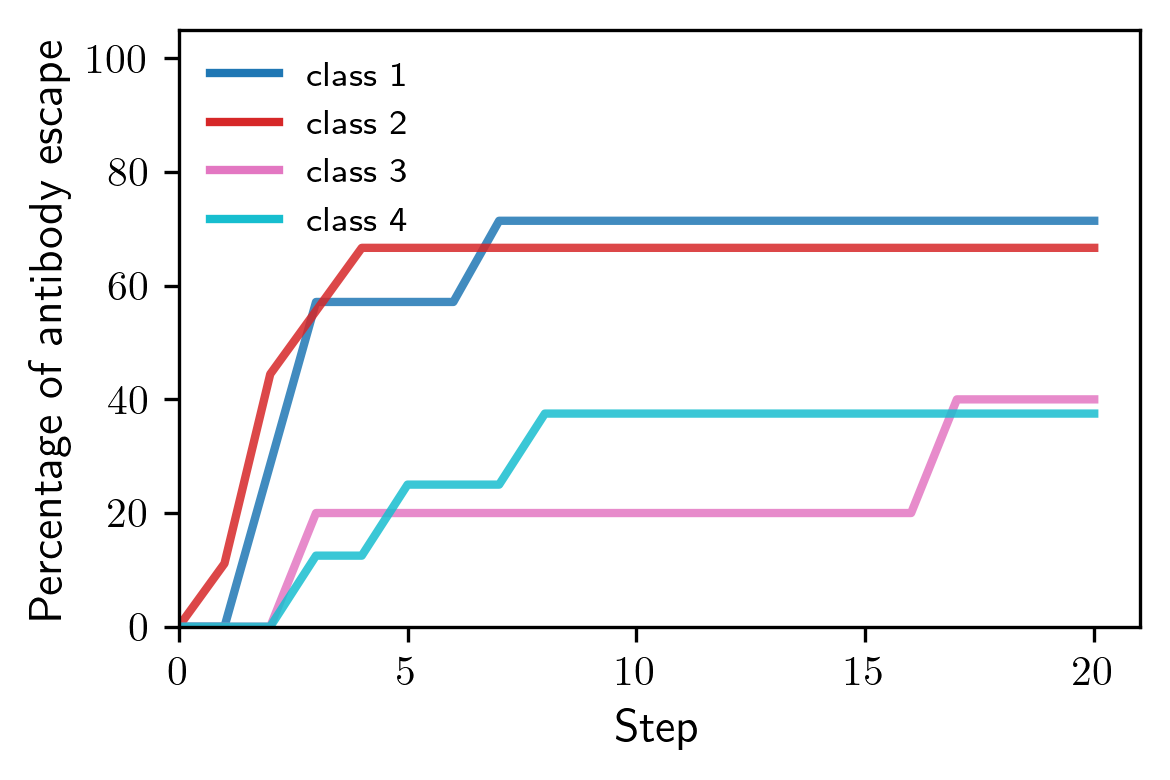

In [ ]:



dir_wt  = 'results_scripts/covid_D_20/'
dir_ba1 = 'results_scripts/covid_D_20_ba1/'

BETA_ABs = [5]
D_FIXED = 1
BINDING_THRESHOLD = 0.1


classes = sorted([c for c, idxs in class_to_indices.items() if len(idxs) > 0])
n_classes = len(classes)

colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))
color_map = {cls: colors[i] for i, cls in enumerate(classes)}

def extract_parameters(path):
    beta_ab_match = re.search(r'beta_ab_(\d+(?:\.\d+)?)', path)
    D_match = re.search(r'D_(\d+)', path)
    return {
        "beta_ab": float(beta_ab_match.group(1)) if beta_ab_match else None,
        "D": int(D_match.group(1)) if D_match else None,
    }

def find_folder(root_dir, target_beta, target_D):
    if not os.path.exists(root_dir):
        return None
    for d in os.listdir(root_dir):
        full_path = os.path.join(root_dir, d)
        if os.path.isdir(full_path):
            params = extract_parameters(d)
            if (params["beta_ab"] is not None and 
                np.isclose(params["beta_ab"], target_beta) and 
                params["D"] == target_D):
                return full_path
    return None

def process_binding_data(folder_path):
    mopt_path = os.path.join(folder_path, "mopt.npy")
    if not os.path.exists(mopt_path):
        return None, 0

    mopt = np.load(mopt_path)[:, :len(ab_names)]
    n_steps = mopt.shape[0]
    
    class_series = {}
    for cls in classes:
        idxs = class_to_indices[cls]
        if len(idxs) == 0:
            class_series[cls] = np.full(n_steps, np.nan)
        else:
            class_log_data = mopt[:, idxs]
            
            class_binding = np.exp(class_log_data)
            
            count_above = np.sum(class_binding >= BINDING_THRESHOLD, axis=1)
            total_abs = len(idxs)
            percentage_above = (count_above / total_abs) * 100.0
            
            class_series[cls] = percentage_above
            
    return class_series, n_steps


variants = [
    ("Wildtype", dir_wt, "-"),    # Solid
]

print(f"Generating separate plots for Betas: {BETA_ABs} (D={D_FIXED})...")

for beta in BETA_ABs:
    if beta != 5:
        continue
    fig = plt.figure(figsize=(4., 2.7), dpi=300)
    ax = plt.gca()
    
    max_steps_in_plot = 0
    data_found = False

    for variant_label, root_dir, style in variants:
        folder = find_folder(root_dir, beta, D_FIXED)
        
        if folder:
            data, steps = process_binding_data(folder)
            
            if data:
                data_found = True
                max_steps_in_plot = max(max_steps_in_plot, steps)
                x_vals = np.arange(steps)
                
                for cls in classes:
                    y_vals = data[cls] # Already calculated as percentage
                    
                    ax.plot(x_vals, 100-y_vals, 
                             color=color_map[cls], 
                             linestyle=style, 
                             linewidth=2, 
                             alpha=0.85)
        else:
            print(f"  [Warning] Missing {variant_label} folder for Beta={beta}")

    ax.set_ylabel("Percentage of antibody escape", fontsize=11)

    ax.set_xlabel("Step", fontsize=11)
    
    ax.set_yscale('linear')
    ax.set_ylim(0, 105) # 0 to 100% with slight padding
    
    if max_steps_in_plot > 0:
        ax.set_xlim(0, max_steps_in_plot)
    
    if data_found:
        legend_elements = []
        for cls in classes:
            legend_elements.append(Line2D([0], [0], color=color_map[cls], lw=2, label=cls))
        
 
        ax.legend(handles=legend_elements, loc='best', frameon=False, fontsize='small')
    else:
        ax.text(0.5, 0.5, "No Data Found", ha='center', transform=ax.transAxes)

    plt.tight_layout()
    plt.show()